**Lasso Regression** 

**Project:** 
- Customer Spending Prediction with Feature Selection 

**Problem Statement:** 
- Predict customer spending behavior and automatically identify important features.

In [20]:
# Step No 1 : Import required libraries
# Import Numerical library
import numpy as np 
# Import pandas library 
import pandas as pd 
# Import Plotting library
import matplotlib.pyplot as plt
# Import Seaborn library
import seaborn as sns 
# Import train test split 
from sklearn.model_selection import train_test_split
# Import Lesso Regression
from sklearn.linear_model import Lasso
# Import evaluation metrics 
from sklearn.metrics import mean_absolute_error , mean_squared_error, r2_score


In [21]:
# Step No 2 : Data Loading and Exploration
import pandas as pd 
df = pd.read_csv("customer_spending_dataset.csv")


In [22]:
# Step No 3 : Understanding the Data

# Display first rows 
print(df.head())
# Display statistical summary 
print(df.describe())
# Display dataset information 
print(df.info())

   Age  Income  Visits  FamilySize  Spending
0   22   25000       5           3     12000
1   25   30000       6           4     15000
2   28   35000       7           4     18000
3   30   40000       8           5     22000
4   32   45000       9           5     25000
             Age        Income     Visits  FamilySize      Spending
count  20.000000     20.000000  20.000000   20.000000     20.000000
mean   34.500000  48950.000000   9.550000    5.500000  29350.000000
std     7.430379  15129.180588   3.034451    1.538968  11837.829637
min    22.000000  25000.000000   5.000000    3.000000  12000.000000
25%    28.750000  36500.000000   7.000000    4.000000  19500.000000
50%    34.500000  49000.000000   9.500000    5.500000  29000.000000
75%    40.250000  60750.000000  12.000000    7.000000  38500.000000
max    47.000000  75000.000000  15.000000    8.000000  50000.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column     

In [23]:
# Step No 4 : Data Cleaning and Preprocessing
# Check missing values 
print(df.isnull().sum())
# check duplicate rows 
print(df.duplicated().sum())
# Remove duplicate rows 
df = df.drop_duplicates()
# all columns names 
print(df.columns)

Age           0
Income        0
Visits        0
FamilySize    0
Spending      0
dtype: int64
0
Index(['Age', 'Income', 'Visits', 'FamilySize', 'Spending'], dtype='object')


In [24]:
# Step No 5 : Features and Target Splitting

# Define input features
X = df[["Age", "Income", "Visits", "FamilySize"]]

# Define target variable
y = df["Spending"]

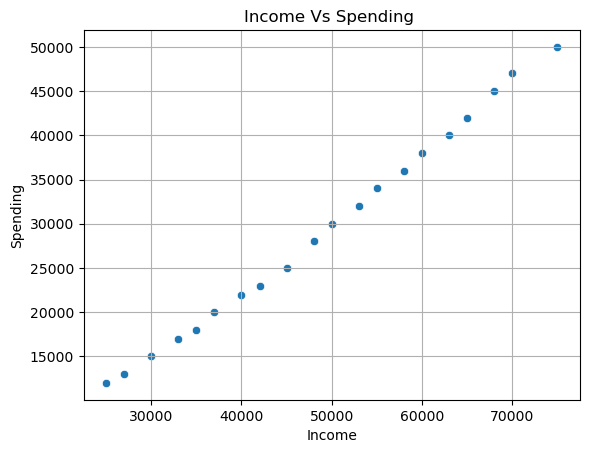

In [25]:
# Step No 6 : Visualization
# Create scatter plot \
sns.scatterplot(x = "Income" , y = "Spending" , data = df)

# Set Plot title 
plt.title("Income Vs Spending ")

# Set x - axis label 
plt.xlabel("Income")

# Set y - axis label 
plt.ylabel("Spending")

# Enable grid 
plt.grid()

# Save fig 
plt.savefig("images/Income Vs Spending(Lasson Regression).png")

# Display the output 
plt.show()

In [26]:
# Step No 7 : Train Test Split for Model Evaluation
# Split data into training and testing
X_train , X_test , y_train , y_test = train_test_split(X ,
                                                       y,
                                                       test_size=0.2,
                                                       random_state=42)

In [27]:
# Step No 8 : Initialize Lasso Regression Model
model = Lasso(alpha=0.1)

In [28]:
# Step No 9 : Model Training
model.fit(X_train , y_train)

c:\Users\sagar\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.760e+06, tolerance: 2.014e+05
  model = cd_fast.enet_coordinate_descent(


,alpha,0.1
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [29]:
# Step No 10 : Prediction
# Predict spending values 
y_pred = model.predict(X_test)

# Display predicted values 
print("Predicted Spending Values : ")
print(y_pred)

Predicted Spending Values : 
[ 8846.66912387 40047.87471986 33201.51275545 13705.16342032]


In [30]:
# Step No 11 : Model Evaluation

# Calculate MAE 
print("Mean Absolute Error : ")
print(mean_absolute_error(y_test , y_pred))

# Calculate MSE 
print("Mean Squared Error : ")
print(mean_squared_error(y_test , y_pred))

# Calculate RMSE 
print("Root Mean Squared Error : ")
print(np.sqrt(mean_squared_error(y_test , y_pred)))

# Calculate R2  Score 
print("R2 Score : ")
print(r2_score(y_test , y_pred))

Mean Absolute Error : 
1424.3887327808297
Mean Squared Error : 
3266505.5681902906
Root Mean Squared Error : 
1807.3476611295046
R2 Score : 
0.9759262602067966


In [36]:
# Step No 12 : Feature Importance
feature_importance = pd.DataFrame({
    "Feature " : X.columns ,
    "Coefficient": model.coef_
})
# display feature importance
print(feature_importance)

     Feature   Coefficient
0         Age  1333.760929
1      Income     0.156194
2      Visits  -126.862745
3  FamilySize   203.104771


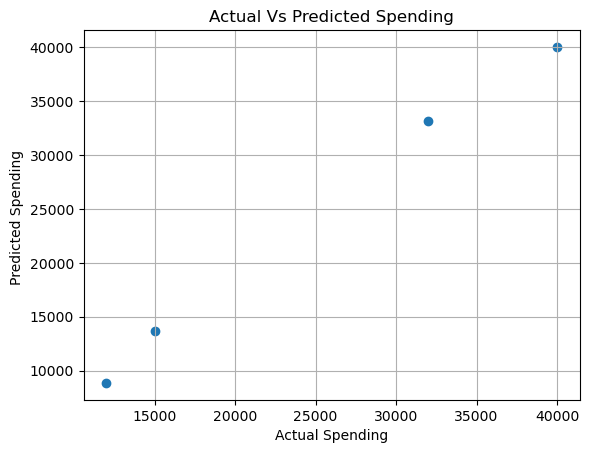

In [37]:
# Step No 13 : Actual vs Predicted Visualization
plt.scatter(y_test ,y_pred)

# Set x-axix title
plt.title("Actual Vs Predicted Spending")

# Set x-axis 
plt.xlabel("Actual Spending")

# Set y-axis 
plt.ylabel("Predicted Spending ")

# Enable Grid 
plt.grid()

# save plot
plt.savefig("images/Actual Vs Predicted Spending(Lasso Regression).png")

# Display Plot 
plt.show()

In [38]:
# Step No 14 : User Input
age = int(input("Enter Age : "))

# Take income input 
income = float(input("Enter Income : "))

# Take monthly visits input 
visits = int(input("Enter Monthly Visits : "))

# Take family size input 
family_size = int(input("Enter Family Size : ")) 

In [39]:
# Step No 15 : Prediction on User Input
user_data = pd.DataFrame({
    "Age": [age],
    "Income": [income],
    "Visits": [visits],
    "FamilySize":[family_size]
})

# Predict customer spending 
result = model.predict(user_data)


In [40]:

# Step No 16 : Final Output
print(f"Predicted Customer Spending is : ₹{result[0]:.2f}")

Predicted Customer Spending is : ₹13634.75
